# 步驟六：模型評估（Evaluation）執行指南

在完成隨機森林、XGBoost、DNN 三個模型的訓練後，評估階段的核心目標是：驗證模型在未見過數據（測試集）上的泛化能力，並挑選出最能平衡「公司授信收益」與「違約損失」的模型與決策門檻。

為了落實「偽陰性代價極高」的業務考量，我們必須先評估模型預測機率的品質，並在計算分類指標前，先確定最佳決策門檻值。

以下是具體執行步驟與思考框架：

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, auc, 
    confusion_matrix, accuracy_score, precision_score, recall_score, fbeta_score
)
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# 設定路徑
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
TARGET_COL = "default_flag"

# 載入模型
rf_model = joblib.load(MODEL_DIR / "rf_model.joblib")
xgb_model = joblib.load(MODEL_DIR / "xgb_model.joblib")
dnn_model = tf.keras.models.load_model(MODEL_DIR / "dnn_model.keras")

# 載入測試資料集
def load_test_data(filename):
    df = pd.read_csv(DATA_DIR / filename)
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]
    return X, y

rf_X_test, rf_y_test = load_test_data("rf_test.csv")
xgb_X_test, xgb_y_test = load_test_data("xgb_test.csv")
dnn_X_test, dnn_y_test = load_test_data("dnn_test.csv")

# 取得模型預測機率
rf_probs = rf_model.predict_proba(rf_X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(xgb_X_test)[:, 1]
dnn_probs = dnn_model.predict(dnn_X_test).flatten()

models_data = {
    "Random Forest": {"y_true": rf_y_test, "probs": rf_probs},
    "XGBoost": {"y_true": xgb_y_test, "probs": xgb_probs},
    "DNN": {"y_true": dnn_y_test, "probs": dnn_probs}
}

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


## 步驟 1：檢視預測機率的分桶違約率（機率校準度 Calibration）

許多人在評估時會直接調用模型的預測類別（$0$ 或 $1$），但在信用風險（先買後付）預測中，預測機率（Probability Scores）的真實物理意義才是靈魂。我們必須檢驗模型預測出的機率，是否與現實中的違約比例相符。

做法：

對 測試集(Test) 輸出模型預測的「用戶違約機率值」。

將預測機率依序等距劃分，每隔 10% 作為一個分桶區間（即：0~10%、11~20%、21~30% ... 91~100%）。

計算每個機率區間內的「實際違約人數佔比」（也就是統計該區間內 default_flag = 1 的比例）。

評估重點：

機率誠實度：如果模型將一群人的預測機率落在 11~20% 區間，那這群人的實際違約率是否真的接近 15% 左右？（若實際違約率高達 40%，代表模型嚴重「低估」風險，在先買後付場景中非常危險）。

過擬合/泛化能力檢查：對比訓練集與測試集在相同分桶下的違約比例是否一致。如果訓練集的機率校準很完美，但測試集在高機率區間的實際違約率卻發生大幅崩跌，代表模型發生了嚴重的過擬合。

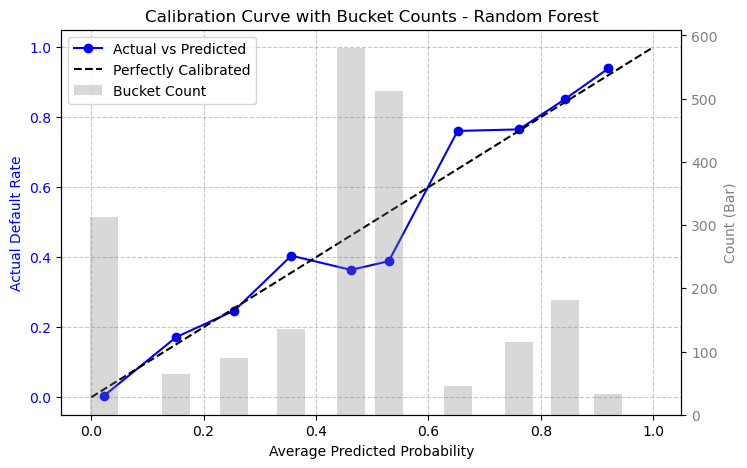

Random Forest Calibration Score: 0.073054


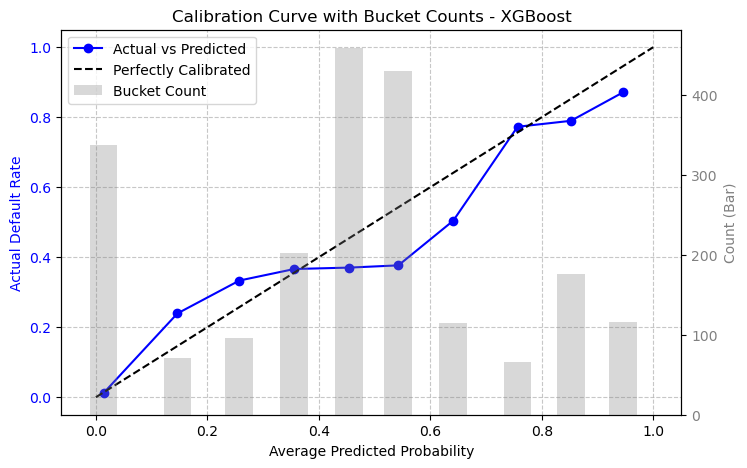

XGBoost Calibration Score: 0.078895


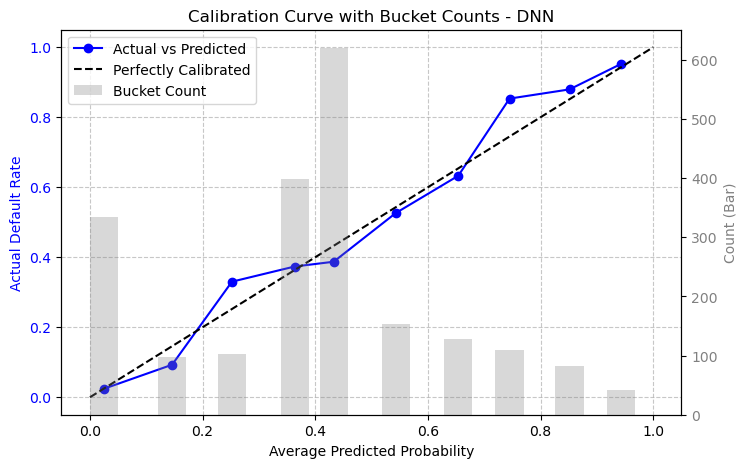

DNN Calibration Score: 0.031587


In [10]:
def plot_calibration(y_true, probs, title):
    # 將機率分為 10 個桶
    df = pd.DataFrame({'True_Label': y_true, 'Predicted_Probability': probs})
    df['Bucket'] = pd.cut(df['Predicted_Probability'], bins=np.arange(0, 1.1, 0.1), include_lowest=True)
    
    # 計算每個桶的實際違約率和平均預測機率
    calibration = df.groupby('Bucket', observed=False).agg(
        Actual_Default_Rate=('True_Label', 'mean'),
        Average_Predicted_Prob=('Predicted_Probability', 'mean'),
        Count=('True_Label', 'count')
    ).reset_index()
    
    # 過濾掉沒有資料的桶
    calibration = calibration.dropna()
    
    # 建立具有雙Y軸的圖表
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # 在次坐標軸畫長條圖顯示各桶的數量
    ax2 = ax1.twinx()
    ax2.bar(calibration['Average_Predicted_Prob'], calibration['Count'], width=0.05, alpha=0.3, color='gray', label='Bucket Count')
    ax2.set_ylabel('Count (Bar)', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    
    # 在主坐標軸畫校準曲線
    ax1.plot(calibration['Average_Predicted_Prob'], calibration['Actual_Default_Rate'], marker='o', color='blue', label='Actual vs Predicted')
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    ax1.set_xlabel('Average Predicted Probability')
    ax1.set_ylabel('Actual Default Rate', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # 合併主次座標軸的圖例
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    plt.title(f'Calibration Curve with Bucket Counts - {title}')
    ax1.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    # 計算 (Actual Default Rate - Average Predicted Probability) 平方乘上 count 佔整體數量的比例後加總
    total_count = calibration['Count'].sum()
    brier_like_score = (abs(calibration['Actual_Default_Rate'] - calibration['Average_Predicted_Prob'])  * (calibration['Count'] / total_count)).sum()
    print(f"{title} Calibration Score: {brier_like_score:.6f}")

for name, data in models_data.items():
    plot_calibration(data['y_true'], data['probs'], name)

## 步驟 2：繪製「雙曲線」評估模型整體的排序與區分能力

在調整任何決策門檻之前，必須先評估模型「區分好壞客戶」的本質能力（不依賴單一門檻）。請繪製以下兩張圖表：

### 1. ROC 曲線與 AUC (Area Under ROC)

原理：以 $False\ Positive\ Rate$（橫軸）與 $True\ Positive\ Rate\ (Recall)$（縱軸）繪製的曲線。

評估點：AUC 越接近 $1.0$ 代表模型對「準時付款」與「違約」的排序能力越好（即能把潛在違約者排在機率較高的位置）。

注意：ROC 曲線在類別不平衡（如違約率僅 $3\%$ ~ $5\%$）時容易顯得過於樂觀。

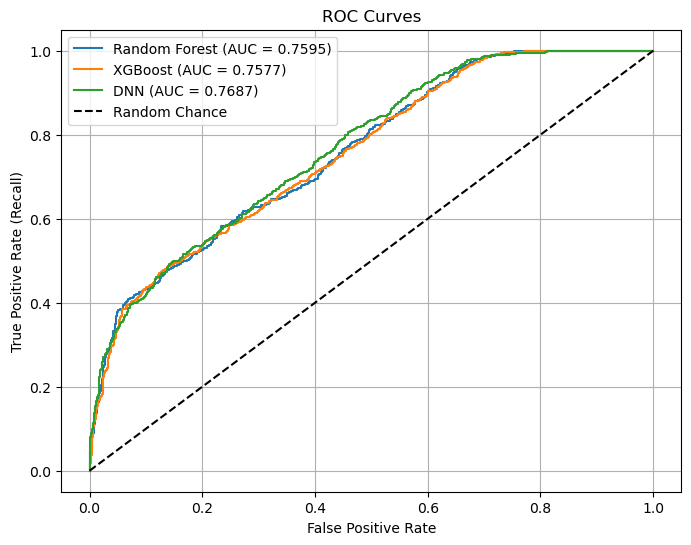

In [3]:
plt.figure(figsize=(8, 6))
for name, data in models_data.items():
    fpr, tpr, _ = roc_curve(data['y_true'], data['probs'])
    auc_score = roc_auc_score(data['y_true'], data['probs'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True)
plt.show()

### 2. PR (Precision-Recall) 曲線與 AUC-PR

原理：以 $Recall$（橫軸）與 $Precision$（縱軸）繪製的曲線。

評估點：在不平衡數據中，PR 曲線更能真實反映模型在「違約（少數類別）」上的預測品質。

判定標準：曲線越往右上方靠近，代表模型越優秀。請優先選擇 PR 曲線包圍面積（AUC-PR）最大的模型。

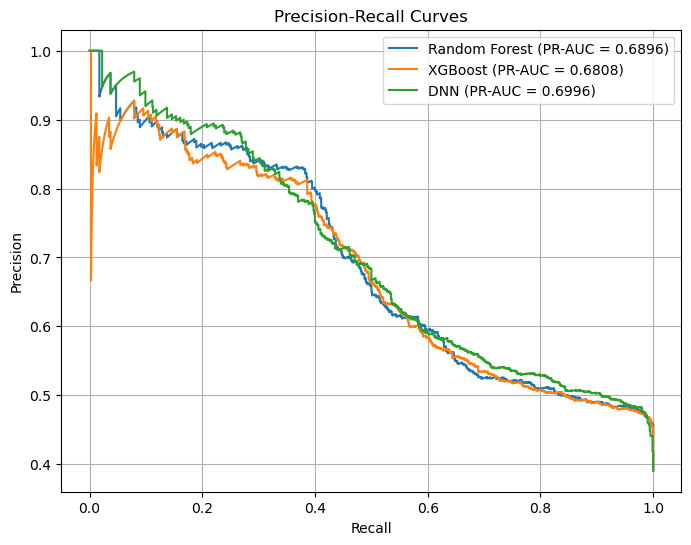

In [4]:
plt.figure(figsize=(8, 6))
for name, data in models_data.items():
    precision, recall, _ = precision_recall_curve(data['y_true'], data['probs'])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.title('Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

## 步驟 3：關鍵優化——尋找與設定「最佳決策門檻值」

得到模型輸出的機率後，我們需要訂定一個恰當的門檻值 $t$（當預測機率 $\ge t$ 時，判定為違約 $1$；反之為 $0$）。以下提供三種在金融風控中最常用的量化設定方法：

最大化 $F_2$-Score 因為你特別重視召回率（Recall），利用測試集計算不同門檻下的 $F_2$-Score，並選擇分數最高的點作為門檻。

$$F_2 = 5 \times \frac{Precision \times Recall}{4 \times Precision + Recall}$$

這會給予 Recall 兩倍於 Precision 的權重，強迫門檻往低處走，主動抓出更多潛在違約者。

In [5]:
best_thresholds = {}

for name, data in models_data.items():
    precision, recall, thresholds = precision_recall_curve(data['y_true'], data['probs'])
    # 計算 F2-score，加上 1e-10 避免除以零錯誤
    f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-10) 
    
    # 找到最大 F2-score 的索引
    # 注意: thresholds 陣列的長度比 precision/recall 少 1
    best_idx = np.argmax(f2_scores[:-1])
    best_thresholds[name] = thresholds[best_idx]
    
    print(f"=== {name} ===")
    print(f"Optimal Threshold (Max F2): {best_thresholds[name]:.4f}")
    print(f"Max F2-Score: {f2_scores[best_idx]:.4f}")
    print("-" * 30)

=== Random Forest ===
Optimal Threshold (Max F2): 0.1534
Max F2-Score: 0.8108
------------------------------
=== XGBoost ===
Optimal Threshold (Max F2): 0.1228
Max F2-Score: 0.8111
------------------------------
=== DNN ===
Optimal Threshold (Max F2): 0.2007
Max F2-Score: 0.8121
------------------------------


## 步驟 4：計算不同門檻下的基本分類指標

在確定了步驟 3 的「最佳門檻 $t_{opt}$」後，我們才能將連續的預測機率轉化為二分類標籤（$0$ 或 $1$）。

請計算各模型在「預設門檻 0.5」與「最佳門檻 $t_{opt}$」兩種設定下的指標，進行對比呈現：

### 1. 混淆矩陣 (Confusion Matrix)：

統計出：真陽性 (TP)、真陰性 (TN)、偽陽性 (FP)、偽陰性 (FN)。

請特別指出並對比優化前後的 FN（漏報違約） 數量。

### 2. 準確率 (Accuracy)：

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

注意：僅供參考。若違約率僅 $5\%$，瞎猜所有人不違約便能得到 $95\%$ 準確率，因此該指標無法反映風控真實價值。

### 3. 精準度 (Precision)：

$$Precision = \frac{TP}{TP + FP}$$

商業意義：在模型預測「會違約」的人群中，實際上真的違約的比例。代表風控審核的精準度（避免誤殺好人，維持客戶體驗）。

### 4. 召回率 (Recall / Sensitivity)：

$$Recall = \frac{TP}{TP + FN}$$

商業意義：在所有實際違約的客戶中，模型成功抓出了多少人。這是你最需要提高的指標（FN 越低，Recall 越高）。

### 5. $F_2$-Score：

$$F_2 = 5 \times \frac{Precision \times Recall}{4 \times Precision + Recall}$$

商業意義：比起平衡的 $F_1$-Score，它更重視 Recall。用來評估模型在偏向風控安全時的綜合表現。

=== Random Forest (Default Threshold: 0.5000) ===
Accuracy:  0.6713
Precision: 0.5721
Recall:    0.6287
F2-Score:  0.6165



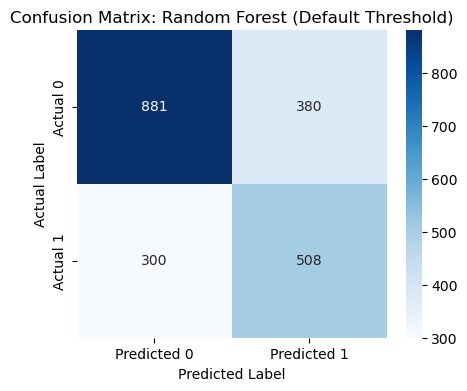

=== Random Forest (Optimal Threshold: 0.1534) ===
Accuracy:  0.5524
Precision: 0.4658
Recall:    0.9950
F2-Score:  0.8108



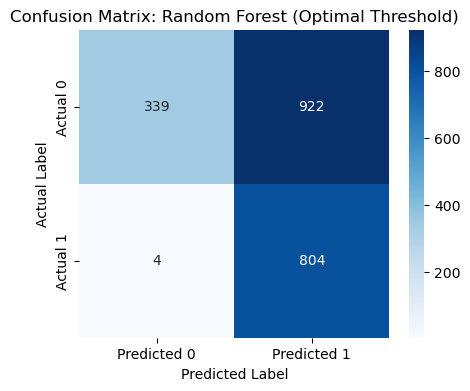

=== XGBoost (Default Threshold: 0.5000) ===
Accuracy:  0.6670
Precision: 0.5659
Recall:    0.6324
F2-Score:  0.6179



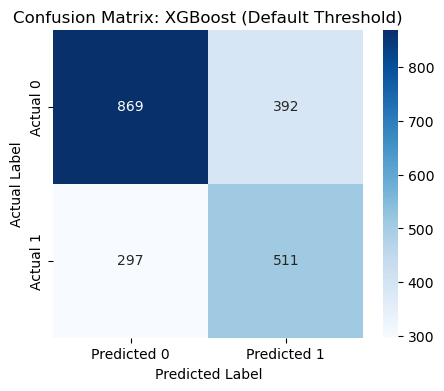

=== XGBoost (Optimal Threshold: 0.1228) ===
Accuracy:  0.5573
Precision: 0.4685
Recall:    0.9926
F2-Score:  0.8111



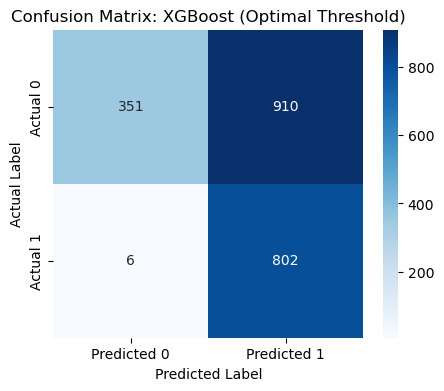

=== DNN (Default Threshold: 0.5000) ===
Accuracy:  0.7158
Precision: 0.7132
Recall:    0.4554
F2-Score:  0.4909



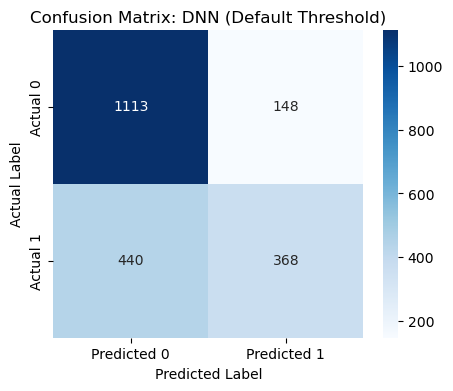

=== DNN (Optimal Threshold: 0.2007) ===
Accuracy:  0.5824
Precision: 0.4829
Recall:    0.9790
F2-Score:  0.8121



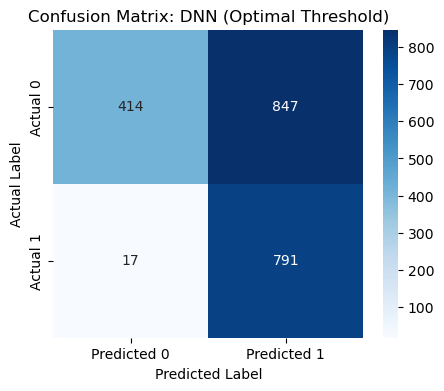

In [6]:
def evaluate_model(y_true, probs, threshold, name, t_type):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)
    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds)
    f2 = fbeta_score(y_true, preds, beta=2, zero_division=0)
    
    print(f"=== {name} ({t_type} Threshold: {threshold:.4f}) ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F2-Score:  {f2:.4f}\n")
    
    # 繪製混淆矩陣熱力圖
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix: {name} ({t_type} Threshold)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

for name, data in models_data.items():
    # 預設門檻 0.5
    evaluate_model(data['y_true'], data['probs'], 0.5, name, "Default")
    # 最佳門檻
    evaluate_model(data['y_true'], data['probs'], best_thresholds[name], name, "Optimal")